<a href="https://colab.research.google.com/github/PalomaSoaresR/FATEC-API-6-SEMESTRE/blob/docs-add-tutorial-notebooks/C%C3%A1lculo_SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo SAM - Usando como exemplo a Distribuidora Energisa_MS

## Guia: Como Adiciona Novos Dados de Concessionárias

Este guia explica os passos necessários para adaptar o cálculo do **SAM (Sistema de Apoio à Manutenção)** para outras distribuidoras ou atualizar os períodos de dados.

### 1. Obter a Base Geográfica (GDB)
As informações de infraestrutura (Religadores, Comprimento de Fio, Conjuntos) vêm de arquivos `.gdb` disponibilizados pela ANEEL ou pela própria distribuidora.
- **O que mudar:** No segundo bloco de código do notebook, altere as variáveis `gdb_download_url`, `gdb_zip_file` e `unzipped_gdb_path` com o link e nome do arquivo da nova concessionária.
- **Onde encontrar:** Geralmente no portal de dados abertos da ANEEL ou SIGEL.

### 2. Atualizar Indicadores de Continuidade (DEC/FEC)
O cálculo de criticidade depende dos valores realizados e das metas (limites) da distribuidora.
- **Filtro de CNPJ:** No bloco de **Tratamento de Dados**, você deve atualizar a variável `cnpj_filter` com o CNPJ da nova distribuidora.
    * *Exemplo: Energisa MS (15.413.826/0001-50) utiliza `15413826000150`.*
- **Ano de Referência:** Se quiser mudar o ano, altere o filtro `AnoIndice` e `AnoLimiteQualidade` (atualmente setados para `2020`).

### 3. Verificar Nomes de Colunas
Embora a maioria das distribuidoras siga o padrão da BDGD (Base de Dados Geográfica da Distribuidora), algumas podem ter variações:
- **SSDMT:** Verifique se a coluna de comprimento se chama `COMP`.
- **UNSEMT:** Verifique se o tipo de unidade de religadores é `32` e a situação ativa é `AT`.
- **CONJ:** Verifique se a chave de ligação entre as tabelas é a coluna `CONJ` ou `COD_ID`.

### 4. Executar o Fluxo de Cálculo
Após alterar os links e o CNPJ:
1. Vá em **Ambiente de Execução** > **Reiniciar e executar tudo**.
2. O código irá baixar os novos arquivos, processar as somas e gerar o gráfico final automaticamente.

### 5. Interpretação do Gráfico
- O gráfico final mostrará o **SAM (KM)**.
- **Fórmula utilizada:** `SAM = (KM de Rede * % de Desvio das Metas) / Qtde de Religadores`.
- Conjuntos com barras maiores no gráfico são aqueles que possuem maior extensão de rede, maior criticidade de interrupção e menos equipamentos de manobra, sendo prioridade para investimentos.

In [ ]:
import pandas as pd
import geopandas as gpd
import os
import zipfile
!pip install -q openpyxl geopandas fiona pyogc

# Download do arquivo
gdb_download_url = 'https://www.arcgis.com/sharing/rest/content/items/975f18dfdb0c479cb237893c5b296ca9/data'
gdb_zip_file = '/content/Energisa_MS_404_2023-12-31_V11_20250923-1616.gdb.zip'
unzipped_gdb_path = '/content/Energisa_MS_404_2023-12-31_V11_20250923-1616.gdb'

if not os.path.exists(gdb_zip_file):
    print(f"Downloading {gdb_download_url} to {gdb_zip_file}...")
    !wget -O {gdb_zip_file} {gdb_download_url}
    print("Download complete.")
else:
    print(f"File {gdb_zip_file} already exists, skipping download.")

# Extrai os arquivos do gdb
if not os.path.exists(unzipped_gdb_path):
    print(f"Unzipping {gdb_zip_file}...")
    with zipfile.ZipFile(gdb_zip_file, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Unzipping complete.")
else:
    print(f"Geodatabase already unzipped at {unzipped_gdb_path}")


# Coleta as Bases CONJ, SSDMT e o UNSEMT para cálculo do SAM
try:
    print(f"Reading CONJ, SSDMT, and UNSEMT layers from {unzipped_gdb_path}...")
    conj = gpd.read_file(unzipped_gdb_path, layer='CONJ')
    ssdmt = gpd.read_file(unzipped_gdb_path, layer='SSDMT')
    unsemt = gpd.read_file(unzipped_gdb_path, layer='UNSEMT')
    print("Successfully loaded CONJ, SSDMT, and UNSEMT from the GDB.")
except Exception as e:
    print(f"Error reading from GDB: {e}")
    conj = None
    ssdmt = None
    unsemt = None

--2026-03-31 19:16:39--  https://www.arcgis.com/sharing/rest/content/items/975f18dfdb0c479cb237893c5b296ca9/data
Resolving www.arcgis.com (www.arcgis.com)... 3.167.152.69, 3.167.152.83, 3.167.152.31, ...
Connecting to www.arcgis.com (www.arcgis.com)|3.167.152.69|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://ago-item-storage.s3.amazonaws.com/975f18dfdb0c479cb237893c5b296ca9/Energisa_MS_404_2023-12-31_V11_20250923-1616.gdb.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEHsaCXVzLWVhc3QtMSJHMEUCIAin3E8AvRgaIsZSvMfiaCbrA6c6GSqecBX6dbGmdww6AiEAz56USMU1ZNQDdCJwoXmJs4MGpR%2BGrunoGUVoxsQFLKkqswUIRBAAGgw2MDQ3NTgxMDI2NjUiDDhRFrElJr%2BPlX386SqQBZU%2FTM07kW2bGUL5nljHEG5GvoFP7ivck7YzSmMJACfj1qVXE1ywXhpdanmtGy26ZfWCP36sh3k3Rp5OayG8IrWfRUl4xfdOOtWnw5IDDUcAcHAiuDVmYxoCriIrpSVW8TlbQRbp94%2BhR6aRMzmbv4ZKF0sWKvK4YS8x%2BE1e3C2jPJpmrkjDB7Hw%2F63PlX21fr8iBK4oxQiMefzzmU34Ut%2BqAxCTAWgk5A5i0YGiZ6Y9Ql%2FEGeFWu9os7ZXCkVEI5WjfqouQo7dQob4VjGAFREi3opLgwpcQl%2BxSGjlJFK6

In [ ]:
#Lê a base conjunto
if conj is not None:
    print("\nCONJ head:")
    display(conj.head())


CONJ head:


,COD_ID,DIST,NOME,SIST_INTE,SIST_SUBT,DESCR,Shape_Length,Shape_Area,geometry
0,15629,404,DOURADOS ALVORADA,1,0,,1.713231,0.126592,"MULTIPOLYGON (((-54.85625 -22.00922, -54.85675..."
1,12805,404,CAARAPO,1,0,,2.612143,0.262879,"MULTIPOLYGON (((-54.59657 -22.54323, -54.59638..."
2,12863,404,MIMOSO,1,0,,3.317999,0.490099,"MULTIPOLYGON (((-53.6257 -20.45397, -53.62517 ..."
3,12869,404,NAVIRAI,1,0,,3.187925,0.352119,"MULTIPOLYGON (((-53.87897 -22.8823, -53.87801 ..."
4,12875,404,NOVA ANDRADINA CASA VERDE,1,0,,4.782730,0.683583,"MULTIPOLYGON (((-53.21233 -21.05339, -53.21076..."


In [ ]:
#Lê a base UNSEMT, que contém a quantidade de religadores
if unsemt is not None:
    print("\nUNSEMT head:")
    display(unsemt.head(10000))


UNSEMT head:


,COD_ID,DIST,PAC_1,PAC_2,FAS_CON,SIT_ATIV,TIP_UNID,P_N_OPE,CAP_ELO,COR_NOM,...,DAT_CON,POS,CTMT,UNI_TR_AT,SUB,CONJ,MUN,ARE_LOC,DESCR,geometry
0,194652510CT,404,74657997747762100MT,74657997747762100ET,ABC,AT,22,F,25K,12,...,31/10/2017,PD,687872,266392,71,12805,5005152,NU,,POINT (-54.59809 -22.79093)
1,194652744CT,404,74604900800669202MT,74604900800669202ET,A,AT,22,F,25K,12,...,31/12/1996,PD,722645,163657,100,12834,5006408,NU,,POINT (-54.6761 -18.01427)
2,194652770CT,404,75260216774451451MT,75260216774451451ET,ABC,AT,22,F,LAM,12,...,31/08/2010,PD,688046,180997,76,16405,5002704,UB,,POINT (-54.57986 -20.38085)
3,194652791CT,404,75273113774472789MT,75273113774472789ET,ABC,AT,22,F,LAM,12,...,31/08/2010,PD,688046,180997,76,16405,5002704,UB,,POINT (-54.57866 -20.3789)
4,194654482CT,404,43189785789420385MT,43189785789420385ET,ABC,AT,22,F,LAM,12,...,30/04/2012,PD,722583,382893,81,12829,5003207,UB,,POINT (-57.64721 -19.04377)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4650783,404,70573041761690303MT,70572935761690412MT,ABC,AT,22,F,6K,12,...,25/07/2019,PD,949096,223414,56,12860,5007208,NU,,POINT (-55.01354 -21.53887)
9996,4650790,404,70423405760774165MT,70423319760774039MT,B,AT,22,F,6K,12,...,25/07/2019,PD,949096,223414,56,12860,5005400,NU,,POINT (-55.02686 -21.62176)
9997,4650793,404,67084348763688676MT,67084481763688751MT,ABC,AT,22,F,15K,12,...,25/07/2019,PD,949060,223414,56,12860,5005400,NU,,POINT (-55.35231 -21.36206)
9998,4650800,404,67172638763374664MT,67172504763374592MT,ABC,AT,22,F,15K,12,...,25/07/2019,PD,949060,223414,56,12860,5005400,NU,,POINT (-55.34348 -21.39033)


In [ ]:
#Lê a base SSDMT, que contém o comprimento do fio
if ssdmt is not None:
    print("\nSSDMT head:")
    display(ssdmt.head())


SSDMT head:


,COD_ID,PN_CON_1,PN_CON_2,CTMT,CT_COD_OP,UNI_TR_AT,SUB,CONJ,ARE_LOC,DIST,...,TIP_CND,POS,ODI,TI,CM,SITCONT,COMP,DESCR,Shape_Length,geometry
0,134351794,134248092,134248093,949218,SIA01,283517,79,12901,UB,404,...,16512364C-3,PD,5,40,999,AT1,34.971,,0.000323,"MULTILINESTRING ((-54.9621 -20.91572, -54.9623..."
1,134351795,134352497,134248094,949218,SIA01,283517,79,12901,UB,404,...,16512364C-3,PD,5,40,999,AT1,2.278,,0.000021,"MULTILINESTRING ((-54.96242 -20.91532, -54.962..."
2,134351796,134248094,134248095,949218,SIA01,283517,79,12901,UB,404,...,16512364C-3,PD,5,40,999,AT1,35.044,,0.000324,"MULTILINESTRING ((-54.96244 -20.9153, -54.9626..."
3,134351797,134352495,134248096,949218,SIA01,283517,79,12901,UB,404,...,16512364C-3,PD,5,40,999,AT1,5.070,,0.000047,"MULTILINESTRING ((-54.96276 -20.91491, -54.962..."
4,134351798,134248096,134248097,949218,SIA01,283517,79,12901,UB,404,...,16512364C-3,PD,5,40,999,AT1,30.398,,0.000282,"MULTILINESTRING ((-54.96279 -20.91487, -54.962..."


In [ ]:
# Carrega o arquivo CSV do DEC e FEC
csv_download_url_1 = 'https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/4493985c-baea-429c-9df5-3030422c71d7/download/indicadores-continuidade-coletivos-2020-2029.csv'
csv_file_1 = '/content/indicadores-continuidade-coletivos-2020-2029.csv'

if not os.path.exists(csv_file_1):
    print(f"Downloading {csv_download_url_1} to {csv_file_1}...")
    !wget -O {csv_file_1} {csv_download_url_1}
    print("Download complete.")
else:
    print(f"File {csv_file_1} already exists, skipping download.")

df_indicadores_2020_2029 = pd.read_csv(csv_file_1, encoding='latin1', sep=';')
print(f"Loaded {csv_file_1}:")
display(df_indicadores_2020_2029.head())

--2026-03-31 19:19:18--  https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/4493985c-baea-429c-9df5-3030422c71d7/download/indicadores-continuidade-coletivos-2020-2029.csv
Resolving dadosabertos.aneel.gov.br (dadosabertos.aneel.gov.br)... 200.198.220.169
Connecting to dadosabertos.aneel.gov.br (dadosabertos.aneel.gov.br)|200.198.220.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 398953661 (380M) [text/csv]
Saving to: ‘/content/indicadores-continuidade-coletivos-2020-2029.csv’

/content/indicadore 100%[===================>] 380.47M  1.23MB/s    in 6m 43s  

2026-03-31 19:26:03 (966 KB/s) - ‘/content/indicadores-continuidade-coletivos-2020-2029.csv’ saved [398953661/398953661]

Download complete.
Loaded /content/indicadores-continuidade-coletivos-2020-2029.csv:


,DatGeracaoConjuntoDados,SigAgente,NumCNPJ,IdeConjUndConsumidoras,DscConjUndConsumidoras,SigIndicador,AnoIndice,NumPeriodoIndice,VlrIndiceEnviado
0,2026-03-05,EAC,4065033000170,12596,São Francisco,FECXP,2020.0,11.0,",00"
1,2026-03-05,EAC,4065033000170,12596,São Francisco,DECIND,2020.0,8.0,",44"
2,2026-03-05,CEA,5965546000109,14571,CALÇOENE,FECINC,2020.0,6.0,",34"
3,2026-03-05,CEA,5965546000109,14571,CALÇOENE,DECIND,2020.0,6.0,",80"
4,2026-03-05,ETO,25086034000171,13650,PALMAS III,FECINO,2020.0,10.0,",00"


In [ ]:
# Carrega o arquivo CSV do DEC e FEC Limite
csv_download_url_2 = 'https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/fd69e1dd-fd66-4269-b60c-cc0b7eb221b4/download/indicadores-continuidade-coletivos-limite.csv'
csv_file_2 = '/content/indicadores-continuidade-coletivos-limite.csv'

if not os.path.exists(csv_file_2):
    print(f"Downloading {csv_download_url_2} to {csv_file_2}...")
    !wget -O {csv_file_2} {csv_download_url_2}
    print("Download complete.")
else:
    print(f"File {csv_file_2} already exists, skipping download.")

df_indicadores_limite = pd.read_csv(csv_file_2, encoding='latin1', sep=';')
print(f"Loaded {csv_file_2}:")
display(df_indicadores_limite.head())

--2026-03-31 19:26:13--  https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/fd69e1dd-fd66-4269-b60c-cc0b7eb221b4/download/indicadores-continuidade-coletivos-limite.csv
Resolving dadosabertos.aneel.gov.br (dadosabertos.aneel.gov.br)... 200.198.220.169
Connecting to dadosabertos.aneel.gov.br (dadosabertos.aneel.gov.br)|200.198.220.169|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21499420 (21M) [text/csv]
Saving to: ‘/content/indicadores-continuidade-coletivos-limite.csv’

/content/indicadore 100%[===================>]  20.50M   847KB/s    in 25s     

2026-03-31 19:26:40 (826 KB/s) - ‘/content/indicadores-continuidade-coletivos-limite.csv’ saved [21499420/21499420]

Download complete.
Loaded /content/indicadores-continuidade-coletivos-limite.csv:


/tmp/ipykernel_7639/2059015137.py:12: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_indicadores_limite = pd.read_csv(csv_file_2, encoding='latin1', sep=';')


,DatGeracaoConjuntoDados,SigAgente,NumCNPJ,IdeConjUndConsumidoras,DscConjUndConsumidoras,SigIndicador,AnoLimiteQualidade,VlrLimite
0,2026-03-05,EDP ES,28152650000171,15394,GUACUI,FEC,1990.0,"8,00"
1,2026-03-05,EQUATORIAL MA,6272793000184,6010,CEMAR CONSOLIDADO,FEC,1996.0,"45,00"
2,2026-03-05,EQUATORIAL PI,6840748000189,6014,CEPISA CONSOLIDADO,FEC,1996.0,"45,00"
3,2026-03-05,ENEL CE,7047251000170,6022,COELCE CONSOLIDADO,FEC,1996.0,"45,00"
4,2026-03-05,Neoenergia PE,10835932000108,6009,CELPE CONSOLIDADO,FEC,1996.0,"45,00"


# Tratamento dos Dados

In [ ]:
# A coluna TIP_UNID indica a localização dos religadores e seu código é 32
# A coluna SIT_ATIV indica se está Ativo ou não, no caso AT indica que está ativo, por isso o filtro
# Link que mostra a localização de um religador: https://www.google.com/maps?q=-19.7333288652349097,-51.92275102444017421
unsemt_filtered = unsemt[(unsemt['TIP_UNID'] == '32') & (unsemt['SIT_ATIV'] == 'AT')]

# Group by CONJ and count unique 'geometry' values
qtde_religadores = unsemt_filtered.groupby('CONJ')['geometry'].nunique().reset_index()
qtde_religadores = qtde_religadores.rename(columns={'geometry': 'Qtde. Religadores'})

print("Qtde. Religadores DataFrame:")
display(qtde_religadores.head(10))

Qtde. Religadores DataFrame:


,CONJ,Qtde. Religadores
0,12785,23
1,12786,67
2,12788,25
3,12791,50
4,12798,14
5,12800,13
6,12803,20
7,12805,21
8,12807,37
9,12811,54


In [ ]:
# Converte a coluna para string
ssdmt['COMP'] = ssdmt['COMP'].astype(str)

# Substitui o '.' pela ',' para quando somar dar o resultado correto
ssdmt['COMP'] = ssdmt['COMP'].str.replace(',', '.', regex=False)

# Convert 'COMP' to numeric. If conversion fails for some values, they will become NaN
ssdmt['COMP'] = pd.to_numeric(ssdmt['COMP'], errors='coerce')

#Elimina as linhas que estão nulas
ssdmt_cleaned = ssdmt.dropna(subset=['COMP'])

# Agrupa por conjunto e soma o total do comprimento do fio em Metros
soma_comprimento_por_conjunto = ssdmt_cleaned.groupby('CONJ')['COMP'].sum().reset_index()
soma_comprimento_por_conjunto = soma_comprimento_por_conjunto.rename(columns={'COMP': 'Soma_Comprimento'})

print("Soma do Comprimento por CONJ (SSDMT):")
display(soma_comprimento_por_conjunto.head(10))

Soma do Comprimento por CONJ (SSDMT):


,CONJ,Soma_Comprimento
0,12785,2181904.130
1,12786,2305187.469
2,12788,759065.494
3,12791,2873927.076
4,12798,710366.355
5,12800,1169134.430
6,12803,1685223.275
7,12805,1058700.610
8,12807,3231092.457
9,12811,876223.190


In [ ]:
# Crie uma cópia para evitar SettingWithCopyWarning
df_indicadores_processed = df_indicadores_2020_2029.copy()

# 1. Tratar a coluna 'VlrIndiceEnviado'
# Substituir vírgula por ponto e converter para numérico
df_indicadores_processed['VlrIndiceEnviado'] = df_indicadores_processed['VlrIndiceEnviado'].astype(str).str.replace(',', '.', regex=False)
df_indicadores_processed['VlrIndiceEnviado'] = pd.to_numeric(df_indicadores_processed['VlrIndiceEnviado'], errors='coerce')

# 2. Filtrar a coluna 'NumCNPJ'
cnpj_filter = 15413826000150
df_indicadores_filtered = df_indicadores_processed[df_indicadores_processed['NumCNPJ'] == cnpj_filter]

# 3. Filtrar a coluna 'Ano Indice' por 2020 para teste
df_indicadores_filtered = df_indicadores_filtered[df_indicadores_filtered['AnoIndice'] == 2020]

# 4. Filtrar a coluna 'SigIndicador' por 'DEC' e 'FEC'
df_indicadores_filtered = df_indicadores_filtered[df_indicadores_filtered['SigIndicador'].isin(['DEC', 'FEC'])]

# 5. Pivotar a coluna 'SIGIndicador' para que DEC e FEC virem colunas
df_pivotado = df_indicadores_filtered.pivot_table(
    index='IdeConjUndConsumidoras',
    columns='SigIndicador',
    values='VlrIndiceEnviado',
    aggfunc='sum'
).reset_index()

# Preencher valores NaN após o pivoteamento com 0, se aplicável
df_pivotado = df_pivotado.fillna(0)

# Renomear colunas para clareza (opcional, pois o pivot_table já as cria com os nomes)
# As colunas já serão 'DEC' e 'FEC' devido ao pivot_table

print("DataFrame processado e pivotado:")
display(df_pivotado.head(100))

DataFrame processado e pivotado:


SigIndicador,IdeConjUndConsumidoras,DEC,FEC
0,12785,18.43,6.04
1,12786,15.84,5.76
2,12788,12.15,7.67
3,12791,9.70,4.36
4,12798,6.23,3.94
5,12800,10.94,4.40
6,12803,96.86,26.35
7,12805,10.44,4.07
8,12807,25.30,8.49
9,12811,5.30,2.78


In [ ]:
# Crie uma cópia para evitar SettingWithCopyWarning
df_indicadores_limite_processed = df_indicadores_limite.copy()

# 1. Tratar a coluna 'VlrIndiceEnviado'
# Substituir vírgula por ponto e converter para numérico
df_indicadores_limite_processed['VlrLimite'] = df_indicadores_limite_processed['VlrLimite'].astype(str).str.replace(',', '.', regex=False)
df_indicadores_limite_processed['VlrLimite'] = pd.to_numeric(df_indicadores_limite_processed['VlrLimite'], errors='coerce')

# 2. Filtrar a coluna 'NumCNPJ'
# Usando o mesmo filtro de CNPJ que foi aplicado anteriormente
cnpj_filter = 15413826000150
df_indicadores_limite_filtered = df_indicadores_limite_processed[df_indicadores_limite_processed['NumCNPJ'] == cnpj_filter]

# 3. Filtrar a coluna 'Ano Indice' por 2020 (ou o ano desejado para os limites)
df_indicadores_limite_filtered = df_indicadores_limite_filtered[df_indicadores_limite_filtered['AnoLimiteQualidade'] == 2020]

# 4. Filtrar a coluna 'SigIndicador' por 'DEC' e 'FEC'
df_indicadores_limite_filtered = df_indicadores_limite_filtered[df_indicadores_limite_filtered['SigIndicador'].isin(['DEC', 'FEC'])]

# 5. Pivotar a coluna 'SigIndicador' para que DEC e FEC virem colunas
df_pivotado_limite = df_indicadores_limite_filtered.pivot_table(
    index='IdeConjUndConsumidoras',
    columns='SigIndicador',
    values='VlrLimite',
    aggfunc='sum'
).reset_index()

# Preencher valores NaN após o pivoteamento com 0, se aplicável
df_pivotado_limite = df_pivotado_limite.fillna(0)

print("DataFrame de Limites processado e pivotado:")
display(df_pivotado_limite.head())

DataFrame de Limites processado e pivotado:


SigIndicador,IdeConjUndConsumidoras,DEC,FEC
0,12785,18.0,9.0
1,12786,9.0,8.0
2,12788,7.0,7.0
3,12791,11.0,8.0
4,12798,8.0,9.0


# Resultado dos Dados

In [ ]:
# Juntar os dois DataFrames
# Certificar que a coluna de merge tem o mesmo tipo em ambos os DataFrames
df_pivotado['IdeConjUndConsumidoras'] = df_pivotado['IdeConjUndConsumidoras'].astype(int)
df_pivotado_limite['IdeConjUndConsumidoras'] = df_pivotado_limite['IdeConjUndConsumidoras'].astype(int)

# Usamos um 'inner' merge para incluir apenas as IdeConjUndConsumidoras presentes em ambos os DataFrames
df_final = pd.merge(df_pivotado, df_pivotado_limite, on='IdeConjUndConsumidoras', suffixes=('_coletivo', '_limite'))

print("DataFrame combinado de Indicadores Coletivos e Limites:")
display(df_final.head())

DataFrame combinado de Indicadores Coletivos e Limites:


SigIndicador,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite
0,12785,18.43,6.04,18.0,9.0
1,12786,15.84,5.76,9.0,8.0
2,12788,12.15,7.67,7.0,7.0
3,12791,9.70,4.36,11.0,8.0
4,12798,6.23,3.94,8.0,9.0


# Realizo o cálculo de criticidade
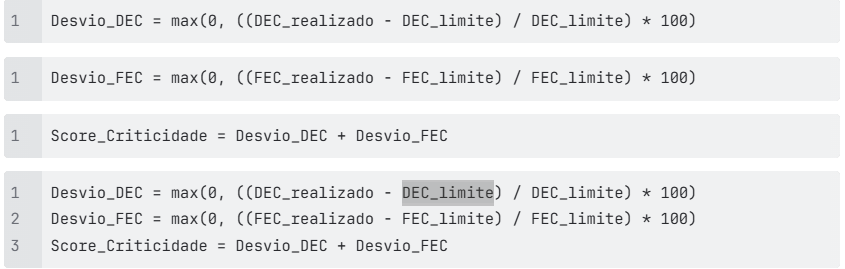

In [ ]:
# Calcula Desvio_DEC
df_final['Desvio_DEC'] = df_final.apply(lambda row: max(0, ((row['DEC_coletivo'] - row['DEC_limite']) / row['DEC_limite']) * 100), axis=1)

# Calcula Desvio_FEC
df_final['Desvio_FEC'] = df_final.apply(lambda row: max(0, ((row['FEC_coletivo'] - row['FEC_limite']) / row['FEC_limite']) * 100), axis=1)

# Calcula Score_Criticidade
df_final['Score_Criticidade'] = df_final['Desvio_DEC'] + df_final['Desvio_FEC']

print("DataFrame final com Desvio_DEC, Desvio_FEC e Score_Criticidade:")
display(df_final.head())

DataFrame final com Desvio_DEC, Desvio_FEC e Score_Criticidade:


SigIndicador,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade
0,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889
1,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000
2,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857
3,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000
4,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000


In [ ]:
# Nessa parte aqui eu Junto a tabela Comprimento Fio
# Certifique-se de que as colunas de junção tenham o mesmo tipo de dado
df_final['IdeConjUndConsumidoras'] = df_final['IdeConjUndConsumidoras'].astype(str)
soma_comprimento_por_conjunto['CONJ'] = soma_comprimento_por_conjunto['CONJ'].astype(str)

# Realizo o merge
df_final = pd.merge(df_final, soma_comprimento_por_conjunto, left_on='IdeConjUndConsumidoras', right_on='CONJ', how='inner')

# Opcional: remover a coluna 'CONJ' duplicada se não for necessária, ou renomeá-la
df_final = df_final.drop(columns=['CONJ'])

print("DataFrame final com comprimento do fio adicionado:")
display(df_final.head())

DataFrame final com comprimento do fio adicionado:


,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento
0,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130
1,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469
2,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494
3,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076
4,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355


In [ ]:
# Certifique-se de que as colunas de junção tenham o mesmo tipo de dado
df_final['IdeConjUndConsumidoras'] = df_final['IdeConjUndConsumidoras'].astype(str)
qtde_religadores['CONJ'] = qtde_religadores['CONJ'].astype(str)

# Realize o merge da tabela Qtde. de religadores
df_final = pd.merge(df_final, qtde_religadores, left_on='IdeConjUndConsumidoras', right_on='CONJ', how='inner')

# remover a coluna 'CONJ'
df_final = df_final.drop(columns=['CONJ'])

print("DataFrame final com quantidade de religadores adicionada:")
display(df_final.head())

DataFrame final com quantidade de religadores adicionada:


,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento,Qtde. Religadores
0,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130,23
1,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469,67
2,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494,25
3,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076,50
4,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355,14


In [ ]:
conj['COD_ID'] = conj['COD_ID'].astype(str)

# Realize o merge para adicionar a coluna 'NOME' para retornar o nome do conjunto
df_final = pd.merge(df_final, conj[['COD_ID', 'NOME']], left_on='IdeConjUndConsumidoras', right_on='COD_ID', how='inner')

# Remover apenas a coluna 'COD_ID', pois 'IdeConjUndConsumidoras' é uma chave importante.
df_final = df_final.drop(columns=['COD_ID'], errors='ignore')

# Reordenar as colunas para que 'NOME' seja a primeira
columns = df_final.columns.tolist()
if 'NOME' in columns:
    columns.remove('NOME')
columns.insert(0, 'NOME')
df_final = df_final[columns]

print("DataFrame final com o nome do conjunto adicionado, colunas removidas e 'NOME' na primeira posição:")
display(df_final.head())

DataFrame final com o nome do conjunto adicionado, colunas removidas e 'NOME' na primeira posição:


,NOME,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento,Qtde. Religadores
0,AGUA CLARA,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130,23
1,AMAMBAI,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469,67
2,APARECIDA DO TABOADO,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494,25
3,AQUIDAUANA,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076,50
4,BATAGUASSU,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355,14


# Realiza o Cálculo SAM
 SAM = (Comprimento do Fio * Criticidade) / Qtde. Religadores



In [ ]:
import numpy as np

# Adiciona uma coluna auxiliar 'Divisor' que será 1 se 'Qtde. Religadores' for 0, senão será 'Qtde. Religadores'
df_final['Divisor'] = np.where(df_final['Qtde. Religadores'] == 0, 1, df_final['Qtde. Religadores'])

# Calcula a coluna 'SAM' usando o 'Divisor' tratado
df_final['SAM'] = (df_final['Soma_Comprimento'] * (df_final['Score_Criticidade']/100)) / df_final['Divisor']

# Opcional: remover a coluna 'Divisor' se não for mais necessária
df_final = df_final.drop(columns=['Divisor'])

print("DataFrame final com a coluna 'SAM' adicionada:")
display(df_final.head(10))

DataFrame final com a coluna 'SAM' adicionada:


,NOME,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento,Qtde. Religadores,SAM
0,AGUA CLARA,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130,23,2266.228927
1,AMAMBAI,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469,67,26148.395171
2,APARECIDA DO TABOADO,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494,25,25244.349572
3,AQUIDAUANA,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076,50,0.000000
4,BATAGUASSU,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355,14,0.000000
5,BONITO,12800,10.94,4.40,13.0,8.0,0.000000,0.000000,0.000000,1169134.430,13,0.000000
6,BONITO CEDERB,12803,96.86,26.35,63.0,35.0,53.746032,0.000000,53.746032,1685223.275,20,45287.031819
7,CAARAPO,12805,10.44,4.07,12.0,8.0,0.000000,0.000000,0.000000,1058700.610,21,0.000000
8,CAMAPUA,12807,25.30,8.49,20.0,11.0,26.500000,0.000000,26.500000,3231092.457,37,23141.608138
9,CAMPO GRANDE - ALMOXARIFADO,12811,5.30,2.78,8.0,7.0,0.000000,0.000000,0.000000,876223.190,54,0.000000


# Gerando gráfico do SAM

In [ ]:
# Gerando uma nova coluna para o comprimento do fio em KM sem alterar o original
df_final['Soma_Comprimento_KM'] = df_final['Soma_Comprimento'] / 1000

print("DataFrame com a nova coluna 'Soma_Comprimento_KM' adicionada:")
display(df_final.head(10))

DataFrame com a nova coluna 'Soma_Comprimento_KM' adicionada:


,NOME,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento,Qtde. Religadores,SAM,Soma_Comprimento_KM
0,AGUA CLARA,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130,23,2266.228927,2181.904130
1,AMAMBAI,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469,67,26148.395171,2305.187469
2,APARECIDA DO TABOADO,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494,25,25244.349572,759.065494
3,AQUIDAUANA,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076,50,0.000000,2873.927076
4,BATAGUASSU,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355,14,0.000000,710.366355
5,BONITO,12800,10.94,4.40,13.0,8.0,0.000000,0.000000,0.000000,1169134.430,13,0.000000,1169.134430
6,BONITO CEDERB,12803,96.86,26.35,63.0,35.0,53.746032,0.000000,53.746032,1685223.275,20,45287.031819,1685.223275
7,CAARAPO,12805,10.44,4.07,12.0,8.0,0.000000,0.000000,0.000000,1058700.610,21,0.000000,1058.700610
8,CAMAPUA,12807,25.30,8.49,20.0,11.0,26.500000,0.000000,26.500000,3231092.457,37,23141.608138,3231.092457
9,CAMPO GRANDE - ALMOXARIFADO,12811,5.30,2.78,8.0,7.0,0.000000,0.000000,0.000000,876223.190,54,0.000000,876.223190


In [ ]:
import numpy as np

# Adiciona uma coluna auxiliar 'Divisor_KM' que será 1 se 'Qtde. Religadores' for 0, senão será 'Qtde. Religadores'
# Isso garante que a nova coluna SAM_KM utilize a mesma lógica de tratamento para religadores zero
df_final['Divisor_KM'] = np.where(df_final['Qtde. Religadores'] == 0, 1, df_final['Qtde. Religadores'])

# Calcula a nova coluna 'SAM_KM' usando 'Soma_Comprimento_KM'
df_final['SAM_KM'] = (df_final['Soma_Comprimento_KM'] * (df_final['Score_Criticidade']/100)) / df_final['Divisor_KM']

# Opcional: remover a coluna 'Divisor_KM' se não for mais necessária
df_final = df_final.drop(columns=['Divisor_KM'])

print("DataFrame final com a nova coluna 'SAM_KM' adicionada:")
display(df_final.head(10))

DataFrame final com a nova coluna 'SAM_KM' adicionada:


,NOME,IdeConjUndConsumidoras,DEC_coletivo,FEC_coletivo,DEC_limite,FEC_limite,Desvio_DEC,Desvio_FEC,Score_Criticidade,Soma_Comprimento,Qtde. Religadores,SAM,Soma_Comprimento_KM,SAM_KM
0,AGUA CLARA,12785,18.43,6.04,18.0,9.0,2.388889,0.000000,2.388889,2181904.130,23,2266.228927,2181.904130,2.266229
1,AMAMBAI,12786,15.84,5.76,9.0,8.0,76.000000,0.000000,76.000000,2305187.469,67,26148.395171,2305.187469,26.148395
2,APARECIDA DO TABOADO,12788,12.15,7.67,7.0,7.0,73.571429,9.571429,83.142857,759065.494,25,25244.349572,759.065494,25.244350
3,AQUIDAUANA,12791,9.70,4.36,11.0,8.0,0.000000,0.000000,0.000000,2873927.076,50,0.000000,2873.927076,0.000000
4,BATAGUASSU,12798,6.23,3.94,8.0,9.0,0.000000,0.000000,0.000000,710366.355,14,0.000000,710.366355,0.000000
5,BONITO,12800,10.94,4.40,13.0,8.0,0.000000,0.000000,0.000000,1169134.430,13,0.000000,1169.134430,0.000000
6,BONITO CEDERB,12803,96.86,26.35,63.0,35.0,53.746032,0.000000,53.746032,1685223.275,20,45287.031819,1685.223275,45.287032
7,CAARAPO,12805,10.44,4.07,12.0,8.0,0.000000,0.000000,0.000000,1058700.610,21,0.000000,1058.700610,0.000000
8,CAMAPUA,12807,25.30,8.49,20.0,11.0,26.500000,0.000000,26.500000,3231092.457,37,23141.608138,3231.092457,23.141608
9,CAMPO GRANDE - ALMOXARIFADO,12811,5.30,2.78,8.0,7.0,0.000000,0.000000,0.000000,876223.190,54,0.000000,876.223190,0.000000


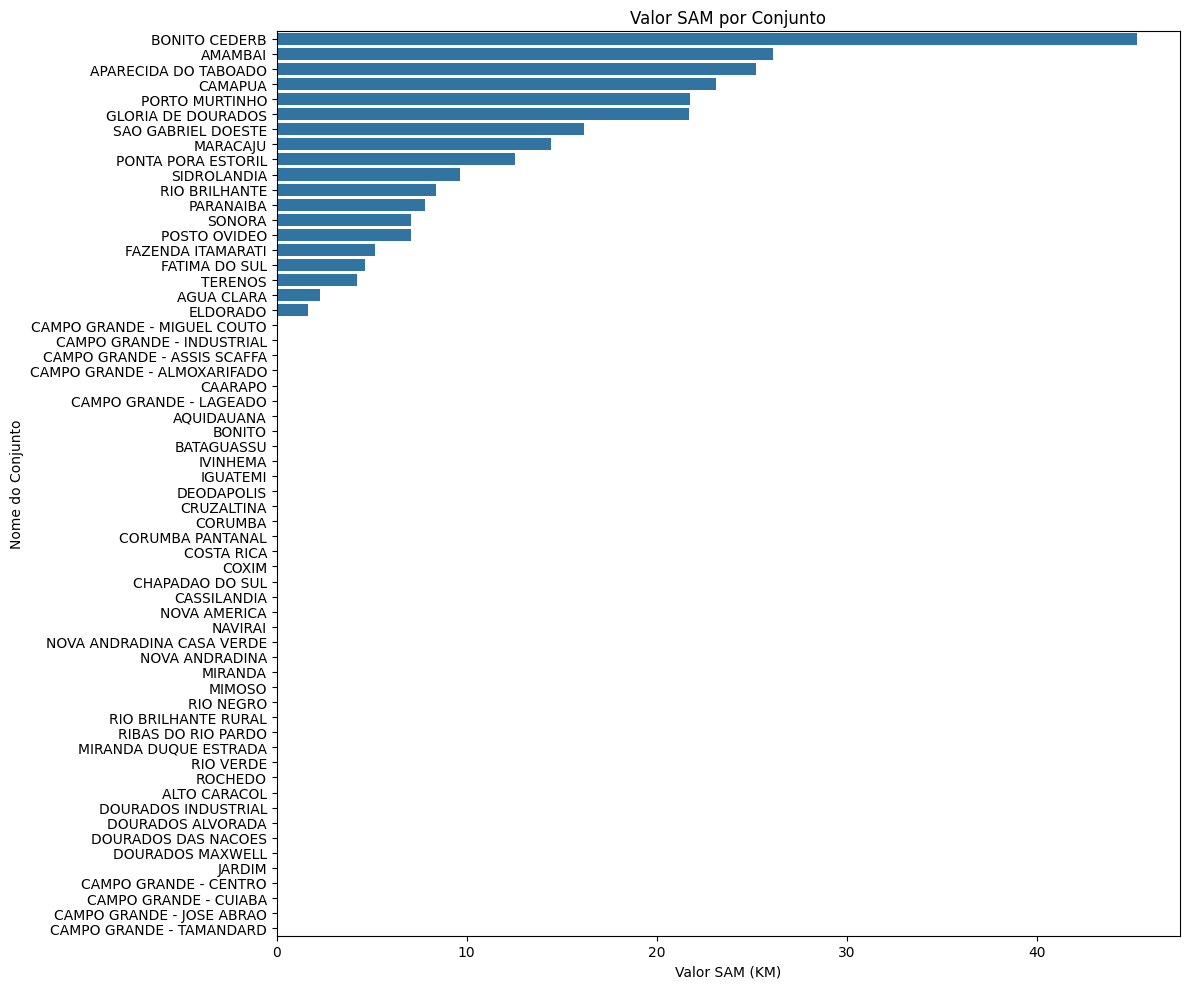

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar os dados para o gráfico, por exemplo, por 'SAM_KM' em ordem crescente (menor para o maior)
df_sorted = df_final.sort_values(by='SAM_KM', ascending=False)

# Criar o gráfico de barras horizontal para 'SAM_KM'
plt.figure(figsize=(12, 10)) # Ajustar o tamanho da figura para melhor visualização horizontal
sns.barplot(x='SAM_KM', y='NOME', data=df_sorted) # Trocar x e y para horizontal
plt.title('Valor SAM por Conjunto')
plt.xlabel('Valor SAM (KM)')
plt.ylabel('Nome do Conjunto')
plt.tight_layout()
plt.show()